In [1]:
import datetime, pickle, os, keras
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from numpy.lib.stride_tricks import sliding_window_view
from src.models.assemble_model import build_detection_model
from src.miscellaneous import create_seq_dataset_multiple_input_single_output
from scipy.stats import hmean

2026-01-21 01:31:25.780649: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-21 01:31:25.786499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768926685.794212   23989 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768926685.796922   23989 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768926685.802728   23989 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
file_name_list = ['data20251222-133102_swing_0_boom_55_1.csv',
                  'data20251222-133551_swing_0_boom_55_2.csv',
                  'data20251222-133904_swing_0_boom_55_3.csv',
                  'data20251222-134228_swing_0_boom_55_4.csv',
                  'data20251222-135532_swing_0_boom_45_1.csv',
                  'data20251222-135826_swing_0_boom_45_2.csv',
                  'data20251222-140154_swing_0_boom_45_3.csv',
                  'data20251222-140457_swing_0_boom_45_4.csv',
                  'data20251222-141357_swing_0_boom_35_1.csv',
                  'data20251222-141645_swing_0_boom_35_2.csv',
                  'data20251222-141951_swing_0_boom_35_3.csv',
                  'data20251222-142245_swing_0_boom_35_4.csv',
                  'data20251223-143719_swing_0_boom_35_5.csv',
                  'data20251223-144010_swing_0_boom_35_6.csv']

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test_15meter', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data['ref_swing_angle(deg)'] = 0
    data_list.append(data)

data = pd.concat(data_list, axis=0)

In [3]:
swing_0_data = data.copy()
swing_0_data = swing_0_data[swing_0_data['boom_angle(deg)'] > 1]
swing_0_data.reset_index(drop=True, inplace=True)
swing_0_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,...,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg),load_ratio,roll_over_state,pred
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,1.16,...,1.38,4.060,0.0,2.43,0.15611,0.0,0,NaN,NaN,NaN
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,...,1.38,4.060,0.0,2.43,0.15518,0.0,0,NaN,NaN,NaN
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,...,1.38,4.060,0.0,2.42,0.15646,0.0,0,NaN,NaN,NaN
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18650,170.285,15.058,34.983,3.681,768.0,-0.598,0.000,-0.40,0.34,1.33,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.28901,0.0,0.0
18651,170.386,15.058,34.983,3.681,768.0,-0.598,0.000,-0.34,0.31,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18652,170.486,15.058,34.983,3.672,772.0,-0.598,0.000,-0.32,0.30,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18653,170.587,15.058,34.983,3.672,772.0,-0.598,0.000,-0.34,0.32,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0


In [4]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']

In [5]:
len_window = 5

for load_cell_name in load_cell_name_list:
    load = swing_0_data[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=len_window), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*(len_window-1))
    swing_0_data[load_cell_name] = filtered_load

swing_0_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,...,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg),load_ratio,roll_over_state,pred
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,0.00,...,0.00,0.000,0.0,0.00,0.15611,0.0,0,NaN,NaN,NaN
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15518,0.0,0,NaN,NaN,NaN
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15646,0.0,0,NaN,NaN,NaN
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15739,0.0,0,NaN,NaN,NaN
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18650,170.285,15.058,34.983,3.681,768.0,-0.598,0.000,-0.40,0.34,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,-0.28901,0.0,0.0
18651,170.386,15.058,34.983,3.681,768.0,-0.598,0.000,-0.34,0.31,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18652,170.486,15.058,34.983,3.672,772.0,-0.598,0.000,-0.32,0.30,1.33,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18653,170.587,15.058,34.983,3.672,772.0,-0.598,0.000,-0.34,0.32,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0


In [6]:
feature_name_list = ['boom_angle(deg)', 'ref_swing_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)',
                     'body_angle_x(deg)', 'body_angle_y(deg)']
target_name = 'roll_over_state'

In [7]:
load_cell_name_list = np.array(load_cell_name_list)

left_diff = np.abs(swing_0_data[load_cell_name_list[0]] - swing_0_data[load_cell_name_list[2]])
left_diff = left_diff.to_numpy()

right_diff = np.abs(swing_0_data[load_cell_name_list[3]] - swing_0_data[load_cell_name_list[5]])
right_diff = right_diff.to_numpy()

left_sum = swing_0_data[load_cell_name_list[0]] + swing_0_data[load_cell_name_list[2]]
left_sum = left_sum.to_numpy()

right_sum = swing_0_data[load_cell_name_list[3]] + swing_0_data[load_cell_name_list[5]]
right_sum = right_sum.to_numpy()

left_ratio = left_diff/(left_sum+0.001)
right_ratio = right_diff/(right_sum+0.001)

load_ratio = 1-hmean([left_ratio, right_ratio], axis=0)

roll_over_state_int = []

for i in load_ratio:
    if i >= 0.3:
        roll_over_state_int.append(0)
    if 0.3 > i >= 0.2:
        roll_over_state_int.append(1)
    if i < 0.2:
        roll_over_state_int.append(2)

swing_0_data['load_ratio'] = load_ratio
swing_0_data[target_name] = np.array(roll_over_state_int)

In [8]:
swing_0_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,...,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg),load_ratio,roll_over_state,pred
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,0.00,...,0.00,0.000,0.0,0.00,0.15611,0.0,0,1.000000,0,NaN
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15518,0.0,0,1.000000,0,NaN
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15646,0.0,0,1.000000,0,NaN
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15739,0.0,0,1.000000,0,NaN
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,0.870983,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18650,170.285,15.058,34.983,3.681,768.0,-0.598,0.000,-0.40,0.34,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,0.447722,0,0.0
18651,170.386,15.058,34.983,3.681,768.0,-0.598,0.000,-0.34,0.31,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,0.447722,0,0.0
18652,170.486,15.058,34.983,3.672,772.0,-0.598,0.000,-0.32,0.30,1.33,...,3.55,34.454,0.0,7.68,NaN,0.0,0,0.469830,0,0.0
18653,170.587,15.058,34.983,3.672,772.0,-0.598,0.000,-0.34,0.32,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,0.467807,0,0.0


<Axes: ylabel='load_ratio'>

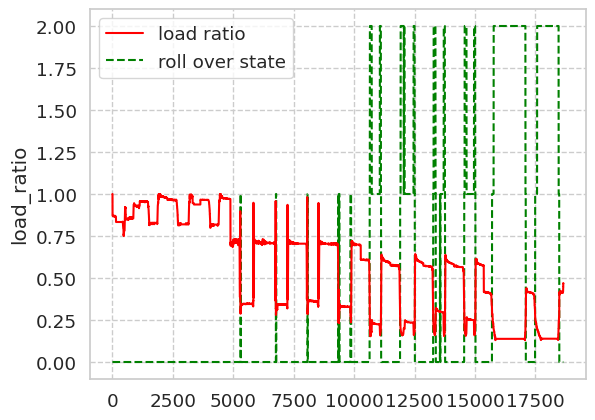

In [9]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=swing_0_data['load_ratio'], color='red', zorder=3, label='load ratio')
sns.lineplot(data=swing_0_data['roll_over_state'], color='green', linestyle='--', label='roll over state')

#plt.xlim(15000, 20000)

<Axes: xlabel='boom_angle(deg)', ylabel='load_ratio'>

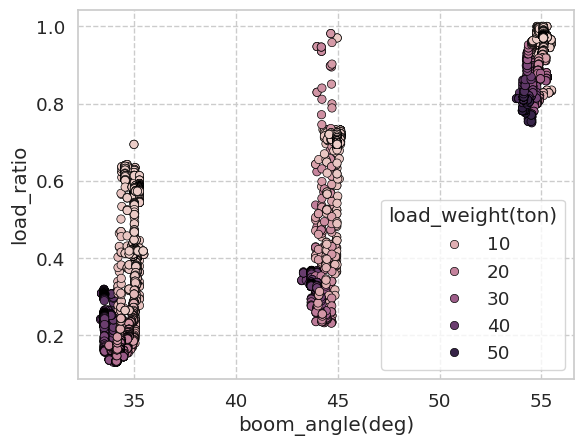

In [10]:
sns.scatterplot(data=swing_0_data, x='boom_angle(deg)', y='load_ratio', hue='load_weight(ton)', edgecolor='black')

<Axes: ylabel='Count'>

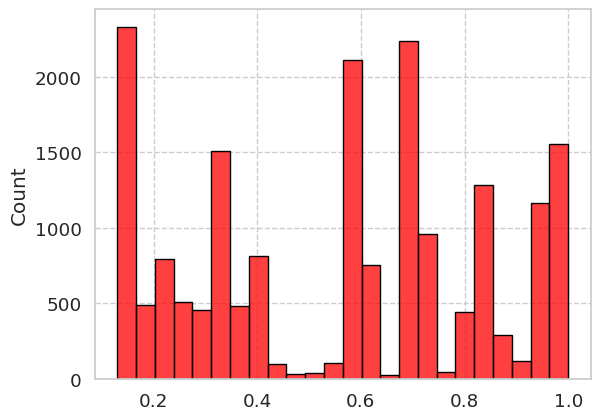

In [11]:
sns.histplot(load_ratio, color='red', edgecolor='black')

In [12]:
swing_0_dataset = swing_0_data[feature_name_list + [target_name]]
swing_0_dataset

,boom_angle(deg),ref_swing_angle(deg),load_weight(ton),engine_speed(rpm),body_angle_x(deg),body_angle_y(deg),roll_over_state
0,55.263,0,2.675,748.0,-0.37,0.12,0
1,55.263,0,2.681,748.0,-0.37,0.11,0
2,55.263,0,2.681,748.0,-0.37,0.11,0
3,55.268,0,2.681,748.0,-0.37,0.11,0
4,55.268,0,2.681,748.0,-0.36,0.11,0
...,...,...,...,...,...,...,...
18650,34.983,0,3.681,768.0,-0.40,0.34,0
18651,34.983,0,3.681,768.0,-0.34,0.31,0
18652,34.983,0,3.672,772.0,-0.32,0.30,0
18653,34.983,0,3.672,772.0,-0.34,0.32,0


In [13]:
file_name_list = ['data20251222-152221_swing_90_boom_55_1.csv',
                  'data20251222-152557_swing_90_boom_55_2.csv']

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test_15meter', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data['ref_swing_angle(deg)'] = 90
    data_list.append(data)

data = pd.concat(data_list, axis=0)

In [14]:
swing_90_data = data.copy()
swing_90_data = swing_90_data[swing_90_data['boom_angle(deg)'] > 1]
swing_90_data.reset_index(drop=True, inplace=True)
swing_90_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg)
0,0.202,15.010,55.203,3.200,748.0,-0.598,25.25,-0.18,0.70,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
1,0.302,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.70,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
2,0.403,15.010,55.203,3.194,748.0,-0.598,25.25,-0.19,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
3,0.503,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
4,0.604,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2350,106.107,15.010,55.203,2.856,748.0,-0.598,25.25,-0.14,0.69,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2351,106.207,15.009,55.198,2.872,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2352,106.308,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2353,106.408,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90


In [15]:
len_window = 5

for load_cell_name in load_cell_name_list:
    load = swing_90_data[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=len_window), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*(len_window-1))
    swing_90_data[load_cell_name] = filtered_load

swing_90_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg)
0,0.202,15.010,55.203,3.200,748.0,-0.598,25.25,-0.18,0.70,0.00,0.00,0.00,0.00,0.0,0.00,0.45918,0.0,90
1,0.302,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.70,0.00,0.00,0.00,0.00,0.0,0.00,0.45918,0.0,90
2,0.403,15.010,55.203,3.194,748.0,-0.598,25.25,-0.19,0.69,0.00,0.00,0.00,0.00,0.0,0.00,0.45918,0.0,90
3,0.503,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,0.00,0.00,0.00,0.00,0.0,0.00,0.45918,0.0,90
4,0.604,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2350,106.107,15.010,55.203,2.856,748.0,-0.598,25.25,-0.14,0.69,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2351,106.207,15.009,55.198,2.872,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2352,106.308,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
2353,106.408,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90


In [16]:
load_cell_name_list = np.array(load_cell_name_list)

left_diff = np.abs(swing_90_data[load_cell_name_list[0]] - swing_90_data[load_cell_name_list[3]])
left_diff = left_diff.to_numpy()

right_diff = np.abs(swing_90_data[load_cell_name_list[2]] - swing_90_data[load_cell_name_list[5]])
right_diff = right_diff.to_numpy()

left_sum = swing_90_data[load_cell_name_list[0]] + swing_90_data[load_cell_name_list[3]]
left_sum = left_sum.to_numpy()

right_sum = swing_90_data[load_cell_name_list[2]] + swing_90_data[load_cell_name_list[5]]
right_sum = right_sum.to_numpy()

left_ratio = left_diff/(left_sum+0.001)
right_ratio = right_diff/(right_sum+0.001)

load_ratio = hmean([left_ratio, right_ratio], axis=0)
roll_over_state_1 = (load_ratio < 0.4)*1
roll_over_state_2 = (load_ratio < 0.35)*1

roll_over_state_int = []

for i in load_ratio:
    if i >= 0.4:
        roll_over_state_int.append(0)
    if 0.4 > i >= 0.35:
        roll_over_state_int.append(1)
    if i < 0.35:
        roll_over_state_int.append(2)

swing_90_data['load_ratio'] = load_ratio
swing_90_data[target_name] = np.array(roll_over_state_int)

<Axes: ylabel='load_ratio'>

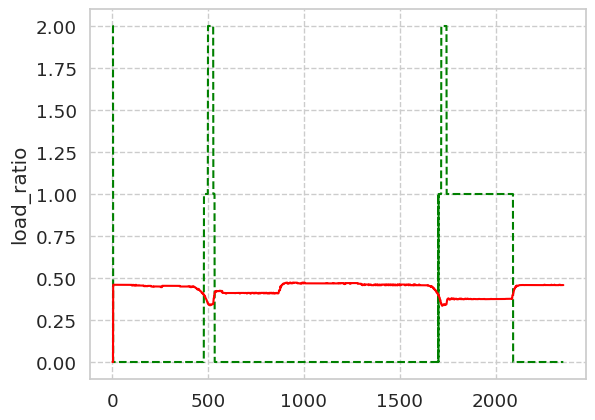

In [17]:
sns.lineplot(swing_90_data['load_ratio'], color='red', zorder=3)
sns.lineplot(swing_90_data[target_name], color='green', linestyle='--')

<Axes: xlabel='boom_angle(deg)', ylabel='load_ratio'>

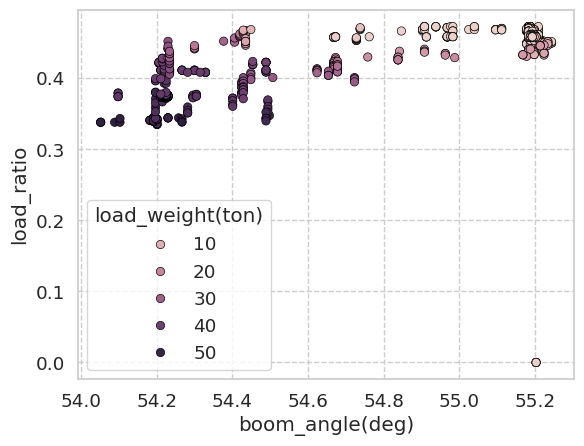

In [18]:
sns.scatterplot(data=swing_90_data, x='boom_angle(deg)', y='load_ratio', hue='load_weight(ton)', edgecolor='black')

In [19]:
swing_90_dataset = swing_90_data[feature_name_list + [target_name]]

In [20]:
dataset = pd.concat([swing_0_dataset, swing_90_dataset], axis=0)
dataset.reset_index(inplace=True, drop=True)

In [21]:
safe_dataset = dataset[dataset['roll_over_state']==0]

train_feature = safe_dataset[feature_name_list].to_numpy()
train_target = safe_dataset[target_name].to_numpy()

n_samples = 500
max_len = 250

random_start_idx = np.random.randint(low=0, high=train_feature.shape[0]-max_len, size=n_samples)
random_len_idx = np.random.randint(low=max_len*2, high=max_len*3, size=n_samples)

feature_buf = np.empty(shape=(0, train_feature.shape[1]))
target_buf = np.empty(shape=(0,))

for i, j in zip(random_start_idx, random_len_idx):
    feature_buf = np.concatenate([feature_buf, train_feature[i:i+j]], axis=0)
    target_buf = np.concatenate([target_buf, train_target[i:i+j]], axis=0)

new_train_feature_1 = feature_buf
new_train_target_1 = target_buf

print(new_train_feature_1.shape, new_train_target_1.shape)

print((new_train_feature_1.itemsize*new_train_feature_1.size)/(1024**2))
print((new_train_target_1.itemsize*new_train_target_1.size)/(1024**2))

(309071, 6) (309071,)
14.148147583007812
2.3580245971679688


In [22]:
train_feature = dataset[feature_name_list].to_numpy()
train_target = dataset[target_name].to_numpy()

n_samples = 1000

a = np.diff(dataset[target_name])
unsafe_start_idx = np.where(a>=1)[0]

random_start_idx = np.random.randint(low=0, high=len(unsafe_start_idx), size=n_samples)

temp_list = []

for i in random_start_idx:
    temp_list.append(unsafe_start_idx[i])

random_start_idx = np.array(temp_list)
random_len_idx = np.random.randint(low=-100, high=0, size=n_samples)

feature_buf = np.empty(shape=(0, train_feature.shape[1]))
target_buf = np.empty(shape=(0,))

for i, j in zip(random_start_idx, random_len_idx):
    feature_buf = np.concatenate([feature_buf, train_feature[i+j:i+max_len]], axis=0)
    target_buf = np.concatenate([target_buf, train_target[i+j:i+max_len]], axis=0)

new_train_feature_2 = feature_buf
new_train_target_2 = target_buf

print(new_train_feature_2.shape, new_train_target_2.shape)

print((new_train_feature_2.itemsize*new_train_feature_2.size)/(1024**2))
print((new_train_target_2.itemsize*new_train_target_2.size)/(1024**2))

(301818, 6) (301818,)
13.816131591796875
2.3026885986328125


In [23]:
new_train_feature = np.concatenate([new_train_feature_1, new_train_feature_2], axis=0)
new_train_target = np.concatenate([new_train_target_1, new_train_target_2], axis=0)
augment_dataset = np.concatenate([new_train_feature, new_train_target.reshape(-1, 1)], axis=1)

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe = OneHotEncoder()

seq_len = 50
pred_distance = 0

train_feature, train_target = create_seq_dataset_multiple_input_single_output(data=augment_dataset,
                                                                              seq_len=seq_len,
                                                                              pred_distance=pred_distance,
                                                                              target_idx_pos=augment_dataset.shape[1]-1)
ohe.fit(train_target)
train_target_enc = ohe.transform(train_target).toarray()

train_feature = train_feature.astype(np.float32)
train_target_enc = train_target_enc.astype(np.float32)

print(train_feature.shape, train_target_enc.shape)
print((train_feature.itemsize*train_feature.size)/(1024**2))
print((train_target_enc.itemsize*train_target_enc.size)/(1024**2))

creating sequence dataset...:   0%|          | 0/610889 [00:00<?, ?it/s]

(610840, 50, 6) (610840, 3)
699.0509033203125
6.990509033203125


In [26]:
active_high_ratio = np.sum(train_target>=1)/train_target.shape[0]
active_low_ratio = np.sum(train_target==0)/train_target.shape[0]

In [27]:
ohe = OneHotEncoder()

val_dataset = dataset[feature_name_list+[target_name]].to_numpy()

val_feature, val_target = create_seq_dataset_multiple_input_single_output(data=val_dataset,
                                                                          seq_len=seq_len,
                                                                          pred_distance=pred_distance,
                                                                  target_idx_pos=val_dataset.shape[1]-1)
ohe.fit(val_target)
val_target_enc = ohe.transform(val_target).toarray()

val_feature = val_feature.astype(np.float32)
val_target_enc = val_target_enc.astype(np.float32)

print(val_feature.shape, val_target_enc.shape)
print((val_feature.itemsize*val_feature.size)/(1024**2))
print((val_target_enc.itemsize*val_target_enc.size)/(1024**2))

creating sequence dataset...:   0%|          | 0/21010 [00:00<?, ?it/s]

(20961, 50, 6) (20961, 3)
23.987960815429688
0.23987960815429688


In [28]:
# active_high_ratio = np.sum(val_target==1)/val_target.shape[0]
# active_low_ratio = np.sum(val_target==0)/val_target.shape[0]

In [29]:
model = build_detection_model(input_shape=train_feature.shape[1:],d_dims=64, dropout_rate=0.5, learning_rate=0.001)
model.summary()

I0000 00:00:1768926691.450213   23989 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 64)    │        448 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 64)    │     12,352 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 64)    │        256 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ add_1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ add_2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 355,331 (1.36 MB)

 Trainable params: 354,563 (1.35 MB)

 Non-trainable params: 768 (3.00 KB)

In [30]:
#keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, show_layer_activations=True, show_dtype=True)


In [31]:
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("--- 모델 파라미터 요약 ---")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {int(trainable_params):,}")
print(f"Non-trainable params: {int(non_trainable_params):,}")

--- 모델 파라미터 요약 ---
Total params: 355,331
Trainable params: 354,563
Non-trainable params: 768


In [32]:
bytes_per_param_float32 = 4
total_bytes = total_params * bytes_per_param_float32

total_kb = total_bytes / 1024
total_mb = total_kb / 1024

print(f"--- 32비트 (float32) 기준 계산 ---")
print(f"총 파라미터 수: {total_params:,}")
print(f"총 용량 (Bytes): {total_bytes:,} Bytes")
print(f"총 용량 (KB): {total_kb:.2f} KB")
print(f"총 용량 (MB): {total_mb:.2f} MB")

--- 32비트 (float32) 기준 계산 ---
총 파라미터 수: 355,331
총 용량 (Bytes): 1,421,324 Bytes
총 용량 (KB): 1388.01 KB
총 용량 (MB): 1.36 MB


In [33]:
train_feature.shape

(610840, 50, 6)

In [34]:
train_target.shape

(610840, 1)

In [ ]:
class_weight = {1: active_low_ratio, 0: active_high_ratio}

time_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = keras.callbacks.TensorBoard(log_dir=f"outputs/log/log_{time_str}", histogram_freq=1)
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=500, verbose=0)
csv_logger = keras.callbacks.CSVLogger(f'outputs/log/log_{time_str}.csv', append=False, separator=',')
model_chk_point = keras.callbacks.ModelCheckpoint(filepath=f'outputs/checkpoints/model_seq_{seq_len}_pred_{pred_distance}_15m.keras', monitor="val_loss", verbose=2, save_best_only=True,
                                                  save_weights_only=False, mode="min", save_freq="epoch", initial_value_threshold=None)

model.fit(x=train_feature, y=train_target_enc, validation_data=(val_feature, val_target_enc), class_weight=class_weight, epochs=999999,
          batch_size=10000, verbose=0, callbacks=[early_stop, model_chk_point, tensorboard_callback])

In [36]:
history = model.history

with open(f'outputs/log/model_seq_{seq_len}_pred_{pred_distance}_history_15m.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [37]:
with open(f'outputs/log/model_seq_{seq_len}_pred_{pred_distance}_history_15m.pkl', 'rb') as f:
    loaded_history = pickle.load(f)

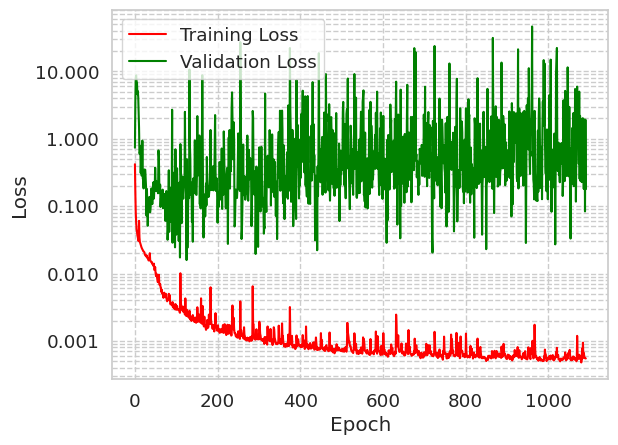

In [38]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

ax = sns.lineplot(loaded_history['loss'], color='red', label='Training Loss')
sns.lineplot(loaded_history['val_loss'], color='green', label='Validation Loss')

plt.xlabel('Epoch')

#plt.ylim(0.0001, 3)
plt.yscale('log')
plt.ylabel('Loss')

plt.grid(True, which='minor', linestyle='--', linewidth=1.0)
formatter = ticker.FuncFormatter(lambda x, p: f'{x:,.3f}')
ax.yaxis.set_major_formatter(formatter)

In [39]:
print(f"max iteration: {len(loaded_history['loss'])}")
print(f"max performance epoch: {np.argmin(loaded_history['val_loss'])}")

max iteration: 1092
max performance epoch: 125
